In [2]:
import pandas as pd
import plotnine as p

In [3]:
truth = pd.read_csv('250522.100papers.tsv', sep = '\t')
results = pd.read_csv('250522.firecrawl.results.csv')

In [4]:
results['DOI'] = results['url'].str.replace('https://doi.org/', '')

In [5]:
df = truth.merge(results, on = ['DOI'])

In [6]:
df

,Shorthand,DOI,Authors,Journal,Title,Date,bioRxiv DOI,Reported cells total,Organism,Tissue,...,RNA Velocity,PCA,tSNE,H5AD location,Isolation,BC --> Cell ID _OR_ BC --> Cluster ID,Number individuals,url,failure_reason,total_number_cells
0,Islam et al NMeth,10.1038/nmeth.2772,"Saiful Islam, Amit Zeisel, Simon Joost, Gioele...",Nat Methods,Quantitative single-cell RNA-seq with unique m...,20131222,-,192,Mouse,Culture,...,NaN,No,No,NaN,IFC Capture,NaN,NaN,https://doi.org/10.1038/nmeth.2772,The total number of cells collected by the aut...,NaN
1,Macosko et al Cell,10.1016/j.cell.2015.05.002,"Evan Z. Macosko, Anindita Basu, Rahul Satija, ...",Cell,Highly Parallel Genome-wide Expression Profili...,20150521,-,"44,808","Human, Mouse",Eye,...,No,Yes,Yes,NaN,Nanodroplet dilution,SCP301,NaN,https://doi.org/10.1016/j.cell.2015.05.002,The total number of cells collected is not spe...,NaN
2,Proserpio et al GBiology,10.1186/s13059-016-0957-5,"Valentina Proserpio, Andrea Piccolo, Liora Hai...",Genome Biol,Single-cell analysis of CD4+ T-cell differenti...,20160512,-,210,Mouse,NaN,...,No,Yes,No,NaN,NaN,NaN,NaN,https://doi.org/10.1186/s13059-016-0957-5,NaN,78.0
3,Treutlein et al Nature,10.1038/nature18323,"Barbara Treutlein, Qian Yi Lee, J. Gray Camp, ...",Nature,Dissecting direct reprogramming from fibroblas...,20160607,-,405,Mouse,Embryo,...,No,Yes,Yes,NaN,NaN,NaN,NaN,https://doi.org/10.1038/nature18323,The total number of cells collected by the aut...,NaN
4,Lake et al Science,10.1126/science.aaf1204,"B. B. Lake, R. Ai, G. E. Kaeser, N. S. Salathi...",Science,Neuronal subtypes and diversity revealed by si...,20160625,-,"3,227",Human,Brain,...,No,NaN,NaN,NaN,IFC Capture,NaN,1.0,https://doi.org/10.1126/science.aaf1204,NaN,3227.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Wei et al Science,10.1126/science.abp9444,"Xiaoyu Wei, Sulei Fu, Hanbo Li, Yang Liu, Shua...",Science,Single-cell Stereo-seq reveals induced progeni...,20220901,NaN,NaN,Axolotl,Brain,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://doi.org/10.1126/science.abp9444,NaN,33.0
96,Pandey et al IJMS,10.3390/ijms231810419,"Ravi S. Pandey, Mark P. Krebs, Mohan T. Bolise...",IJMS,Single-Cell RNA Sequencing Reveals Molecular F...,20220909,NaN,"5,513",Mouse,Retina,...,NaN,Yes,NaN,NaN,NaN,NaN,NaN,https://doi.org/10.3390/ijms231810419,NaN,2667.0
97,Lin et al NCommunications,10.1038/s41467-022-33140-z,"Jing-Ping Lin, Hannah M. Kelly, Yeajin Song, R...",Nat Commun,Transcriptomic architecture of nuclei in the m...,20220921,NaN,"500,000",Marmoset,Brain,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://doi.org/10.1038/s41467-022-33140-z,NaN,500000.0
98,Zhang et al Science,10.1126/science.adn3949,"Zehao Zhang, Chloe Schaefer, Weirong Jiang, Zi...",Science,A panoramic view of cell population dynamics i...,20241128,10.1101/2024.03.01.583001,"21,786,931",Mouse,"Brain, Lung, Heart, Liver, Kidney, Muscle, Sto...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://doi.org/10.1126/science.adn3949,NaN,21786931.0


In [7]:
# Convert the necessary columns to numeric types
df["Reported cells total"] = pd.to_numeric(
    df["Reported cells total"].str.replace(',', ''), errors='coerce'
)
df["total_number_cells"] = pd.to_numeric(
    df["total_number_cells"], errors='coerce'
)

/Users/val/miniforge3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
/Users/val/miniforge3/lib/python3.12/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 37 rows containing missing values.


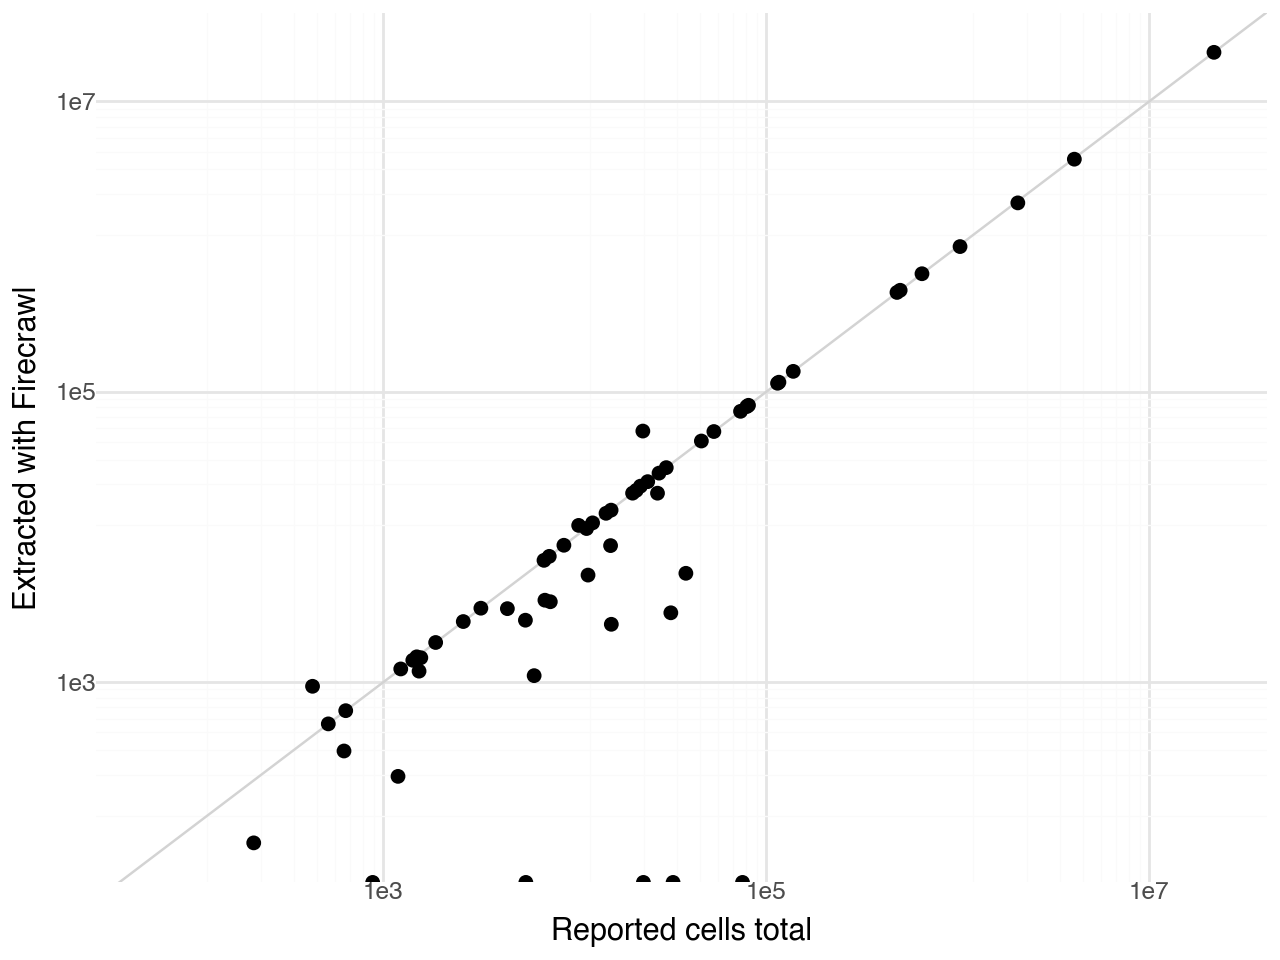

In [8]:
# Filter out rows where 'Reported cells total' is NA
plot_df = df[df['Reported cells total'].notna()]

(
    p.ggplot(plot_df)
    + p.aes(x = 'Reported cells total', y = 'total_number_cells')
    + p.geom_abline(color = 'lightgrey')
    + p.geom_point(size = 2)
    + p.geom_point(
        data=plot_df[plot_df['total_number_cells'].isna()],
        mapping=p.aes(x='Reported cells total'),
        y=22,
        color='red',
        size = 2
    )
    + p.scale_x_log10()
    + p.scale_y_log10()
    + p.theme_minimal()
    + p.theme(panel_background=p.element_rect(fill='white'))
    + p.labs(y = 'Extracted with Firecrawl')
)

/Users/val/miniforge3/lib/python3.12/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/val/miniforge3/lib/python3.12/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Figure1.png
/Users/val/miniforge3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
/Users/val/miniforge3/lib/python3.12/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 37 rows containing missing values.
/Users/val/miniforge3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
/Users/val/miniforge3/lib/python3.12/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 37 rows containing missing values.


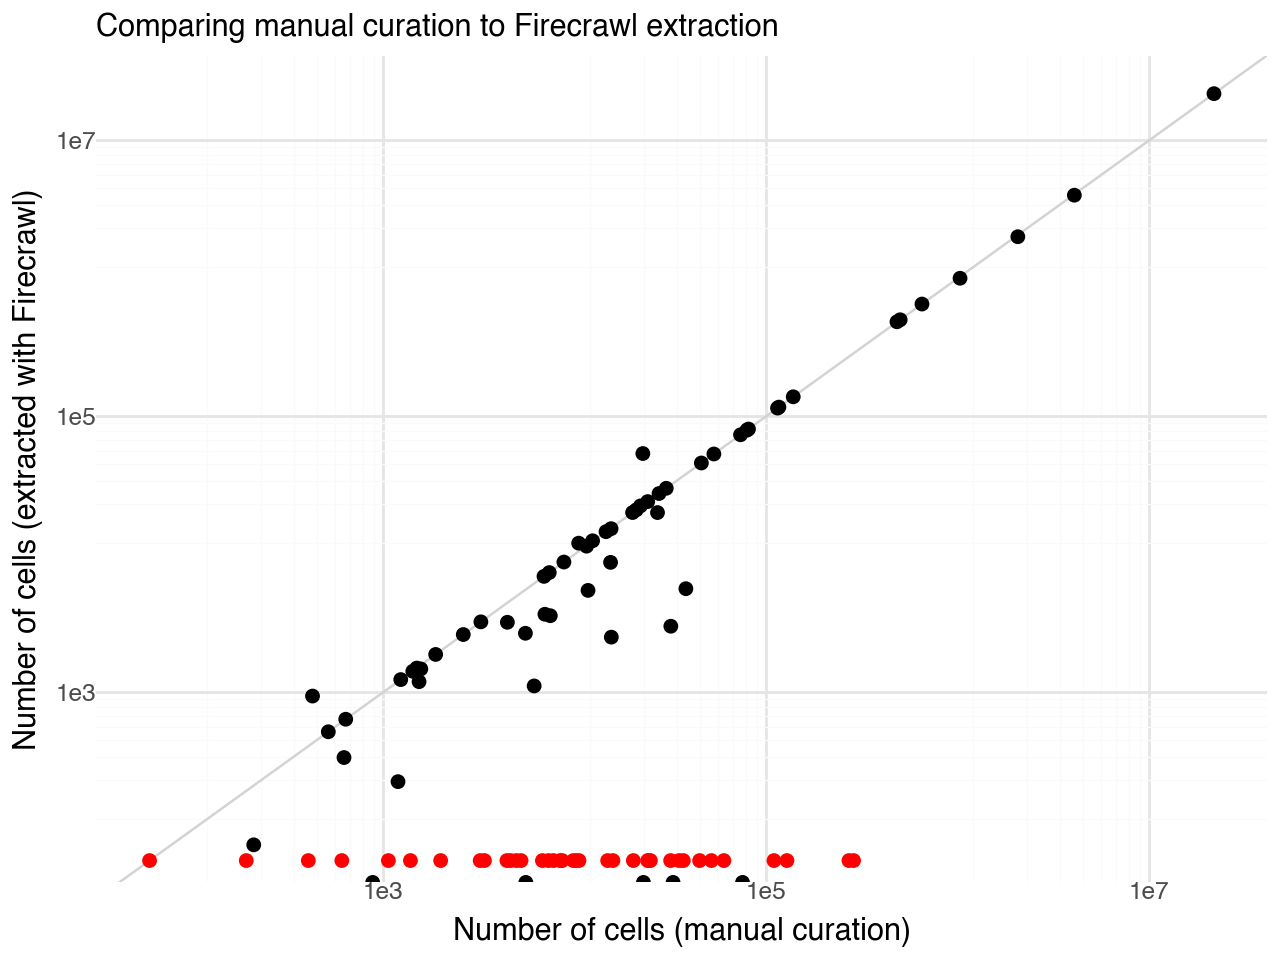

In [26]:
# Filter out rows where 'Reported cells total' is NA
plot_df = df[df['Reported cells total'].notna()]

p_ = (
    p.ggplot(plot_df)
    + p.aes(x = 'Reported cells total', y = 'total_number_cells')
    + p.geom_abline(color = 'lightgrey')
    + p.geom_point(size = 2)
    + p.geom_point(
        data=plot_df[plot_df['total_number_cells'].isna()],
        mapping=p.aes(x='Reported cells total'),
        y=60,
        color='red',
        size = 2
    )
    + p.scale_x_log10()
    + p.scale_y_log10()
    + p.theme_minimal()
    + p.theme(panel_background=p.element_rect(fill='white'))
    + p.labs(
        x = 'Number of cells (manual curation)',
        y = 'Number of cells (extracted with Firecrawl)',
        subtitle = 'Comparing manual curation to Firecrawl extraction'
    )
)

p_.save('Figure1.png', dpi = 300)

p_ 

In [10]:
df[["Reported cells total", 'total_number_cells']]

,Reported cells total,total_number_cells
0,192.0,NaN
1,44808.0,NaN
2,210.0,78.0
3,405.0,NaN
4,3227.0,3227.0
...,...,...
95,NaN,33.0
96,5513.0,2667.0
97,500000.0,500000.0
98,21786931.0,21786931.0


In [11]:
df['Reported cells total'].isna().sum()

np.int64(3)

In [12]:
df.query('`Reported cells total` == total_number_cells').shape

(26, 31)

In [13]:
df['total_number_cells'].isna().sum()

np.int64(37)

In [14]:
df.query('`Reported cells total` != total_number_cells').shape

(74, 31)

In [38]:
# Calculate the requested statistics
# Only consider rows where 'Reported cells total' is not NA
valid_df = df[df['Reported cells total'].notna()]
total_valid_rows = len(valid_df)

# Percent of numbers that match between 'Reported cells total' and total_number_cells
matching_rows = valid_df.query('`Reported cells total` == total_number_cells').shape[0]
percent_match = (matching_rows / total_valid_rows) * 100

# Percent with NA in total_number_cells (among valid rows)
na_total_number = valid_df['total_number_cells'].isna().sum()
percent_na = (na_total_number / total_valid_rows) * 100

# Percent that are not equal (among valid rows)
not_equal_rows = valid_df.query('`Reported cells total` != total_number_cells').shape[0]
percent_not_equal = (not_equal_rows / total_valid_rows) * 100

not_equal_rows = total_valid_rows - matching_rows - na_total_number
percent_not_equal = (not_equal_rows / total_valid_rows) * 100
print(f"Total papers with valid 'Reported cells total': {total_valid_rows}")
print(f"Papers with matching cell counts: {matching_rows} ({percent_match:.1f}%)")
print(f"Papers with NA in total_number_cells: {na_total_number} ({percent_na:.1f}%)")
print(f"Papers with non-matching cell counts: {not_equal_rows} ({percent_not_equal:.1f}%)")

Total papers with valid 'Reported cells total': 97
Papers with matching cell counts: 26 (26.8%)
Papers with NA in total_number_cells: 37 (38.1%)
Papers with non-matching cell counts: 34 (35.1%)


In [44]:
# Calculate error on log-log scale for non-matching, non-NA cases, filtering out cases with total_number_cells equal to 0.0
import numpy as np

# Filter for cases where both values are present but not equal and total_number_cells is not 0.0
error_df = df[
    (df['Reported cells total'].notna()) & 
    (df['total_number_cells'].notna()) & 
    (df['Reported cells total'] != df['total_number_cells']) &
    (df['total_number_cells'] != 0.0)
]

print(f"Papers with both values present but not equal: {len(error_df)}")

if len(error_df) > 0:
    # Check for zero or negative values that would cause issues with log10
    print(f"Min reported cells: {error_df['Reported cells total'].min()}")
    print(f"Min extracted cells: {error_df['total_number_cells'].min()}")
    
    # Filter out zero or negative values before taking log
    valid_error_df = error_df[
        (error_df['Reported cells total'] > 0) & 
        (error_df['total_number_cells'] > 0)
    ]
    
    print(f"Papers after removing zero/negative values: {len(valid_error_df)}")
    
    if len(valid_error_df) > 0:
        # Calculate log10 difference (error on log scale)
        log_reported = np.log10(valid_error_df['Reported cells total'])
        log_extracted = np.log10(valid_error_df['total_number_cells'])
        log_error = np.abs(log_reported - log_extracted)
        
        print(f"Log10 error statistics:")
        print(f"  Mean: {log_error.mean():.2f}")
        print(f"  Median: {log_error.median():.2f}")
        print(f"  Min: {log_error.min():.2f}")
        print(f"  Max: {log_error.max():.2f}")
        print(f"  Standard deviation: {log_error.std():.2f}")
        
        # Convert median log10 error to fold change error
        median_log_error = log_error.mean()
        fold_change_error = 10**median_log_error
        print(f"Mean fold change error: {fold_change_error:.1f}x")
        
        # Show some examples
        print(f"\nFirst 5 examples:")
        for i, (idx, row) in enumerate(valid_error_df.head().iterrows()):
            reported = row['Reported cells total']
            extracted = row['total_number_cells']
            error = log_error.iloc[i]
            fold_error = 10**error
            print(f"  {reported:>8,.0f} vs {extracted:>8,.0f} (log error: {error:.2f}, fold error: {fold_error:.1f}x)")
    else:
        print("No valid cases after removing zero/negative values")
else:
    print("No cases found with both values present but not equal")

# Additionally, include error statistics for all cases (including those with equal values)
all_valid_df = df[
    (df['Reported cells total'].notna()) &
    (df['total_number_cells'].notna()) &
    (df['Reported cells total'] > 0) &
    (df['total_number_cells'] > 0)
]

print(f"Total papers with both values > 0: {len(all_valid_df)}")

if len(all_valid_df) > 0:
    log_reported_all = np.log10(all_valid_df['Reported cells total'])
    log_extracted_all = np.log10(all_valid_df['total_number_cells'])
    log_error_all = np.abs(log_reported_all - log_extracted_all)

    print("Error statistics (including matching cases):")
    print(f"  Mean: {log_error_all.mean():.2f}")
    print(f"  Median: {log_error_all.median():.2f}")
    print(f"  Min: {log_error_all.min():.2f}")
    print(f"  Max: {log_error_all.max():.2f}")
    print(f"  Standard deviation: {log_error_all.std():.2f}")

    median_log_error_all = log_error_all.mean()
    fold_change_error_all = 10**median_log_error_all
    print(f"Mean fold change error (including matching cases): {fold_change_error_all:.1f}x")
else:
    print("No valid cases with both values > 0")

Papers with both values present but not equal: 29
Min reported cells: 210.0
Min extracted cells: 78.0
Papers after removing zero/negative values: 29
Log10 error statistics:
  Mean: 0.26
  Median: 0.14
  Min: 0.00
  Max: 1.02
  Standard deviation: 0.30
Mean fold change error: 1.8x

First 5 examples:
       210 vs       78 (log error: 0.43, fold error: 2.7x)
    10,461 vs   12,000 (log error: 0.06, fold error: 1.1x)
    27,000 vs   20,000 (log error: 0.13, fold error: 1.3x)
       426 vs      935 (log error: 0.34, fold error: 2.2x)
       622 vs      335 (log error: 0.27, fold error: 1.9x)
Total papers with both values > 0: 55
Error statistics (including matching cases):
  Mean: 0.14
  Median: 0.00
  Min: 0.00
  Max: 1.02
  Standard deviation: 0.25
Mean fold change error (including matching cases): 1.4x


In [36]:
(
    df
    .query('`Reported cells total` != total_number_cells')
    .filter(items = ['Reported cells total', 'total_number_cells'])
    .dropna()
)

,Reported cells total,total_number_cells
2,210.0,78.0
9,10461.0,12000.0
17,27000.0,20000.0
18,426.0,935.0
20,622.0,335.0
23,6971.0,3663.0
24,1567.0,1471.0
26,7438.0,3575.0
27,1534.0,1189.0
28,4438.0,3204.0
